# Build Your Own AI Agents with LangGraph & Gemini

<table align="left">
  <td style="text-align: center">
    <a href="https://colab.research.google.com/github/tahreemrasul/langgraph/blob/main/langgraph_gemini_podcast_vertexai.ipynb">
      <img width="32px" src="https://www.gstatic.com/pantheon/images/bigquery/welcome_page/colab-logo.svg" alt="Google Colaboratory logo"><br> Open in Colab
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://github.com/tahreemrasul/langgraph/blob/main/langgraph_gemini_podcast_vertexai.ipynb">
      <img width="32px" src="https://www.svgrepo.com/download/217753/github.svg" alt="GitHub logo"><br> View on GitHub
    </a>
  </td>
</table>

<div style="clear: both;"></div>    

| Author |
| --- |
| [Tahreem Rasul](https://github.com/tahreemrasul/) |

Welcome to this hands-on workshop where we'll progressively build up your understanding of AI agents using **LangGraph**, powered by **Gemini**.

We'll start simple and gradually build up to a full-featured autonomous agent. Here's what we'll cover:

---

## Table of Contents

#### 1. **Graphs**
- **Graph I - V:** Learn LangGraph fundamentals by constructing simple graphs that help you understand how nodes, edges, state, and execution paths work.

#### 2. **Setup**
- Get started with your environment
- Install all required packages
- Authenticate Google Colab with your Google account
- Set up your Vertex AI project

#### 3. **Agent**
- **ReAct Agent:** Build a simple reasoning-and-action agent using LangGraph + Gemini

#### 4. **AI-Powered Podcast Creation Agent**  
Take a deep dive into a creative application of agents — automatically researching, writing, refining, and even narrating a podcast.

---

## Structure

We'll progress in three stages:

1. **Foundations:** Learn graph structure through mini examples (Graph I-V)
2. **ReAct Agent:** Build a practical single-agent system to understand tool usage
3. **Podcast Agent:** Apply everything you've learned in a creative, multi-tool pipeline that combines search, memory, planning, critique, and generation — all powered by Gemini

By the end of this workshop, you'll not only understand how to build LangGraph agents, but you'll also walk away with a fully functional AI system that performs meaningful tasks end-to-end.

Let's get started!


# Graphs

## Graph I

In [1]:
!pip install -q langgraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.9/154.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 kB 4.6 MB/s eta 0:00:00


In [2]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph # framework that helps you design and manage the flow of tasks in your application using a graph structure

In [3]:
# We now create an AgentState - shared data structure that keeps track of information as your application runs.

class AgentState(TypedDict): # Our state schema
    message : str


def greeting_node(state: AgentState) -> AgentState:
    """Simple node that adds a greeting message to the state"""

    state['message'] = "Hey " + state["message"] + ", how is your day going?"

    return state

In [4]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)

graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app = graph.compile()

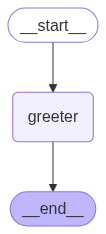

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [14]:
result = app.invoke({"message": "Tayyababc"})

In [12]:
result["message"]

'Hey Tayyababc, how is your day going?'

## Graph II

In [15]:
graph = None
app = None

In [16]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [17]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str

In [18]:
def process_values(state: AgentState) -> AgentState:
    """This function handles multiple different inputs"""
    print(state)

    state["result"] = f"Hi there {state['name']}! Your sum = {sum(state['values'])}"

    print(state)
    return state

In [19]:
graph = StateGraph(AgentState)

graph.add_node("processor", process_values)
graph.set_entry_point("processor") # Set the starting node
graph.set_finish_point("processor") # Set the ending node

app = graph.compile() # Compiling the graph

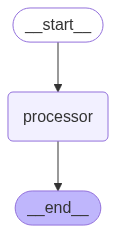

In [20]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
answers = app.invoke({"values": [1,2,3,4], "name": "Steve"})

{'values': [1, 2, 3, 4], 'name': 'Steve'}
{'values': [1, 2, 3, 4], 'name': 'Steve', 'result': 'Hi there Steve! Your sum = 10'}


In [22]:
print(answers["result"])

Hi there Steve! Your sum = 10


## Graph III

In [23]:
graph = None
app = None

In [24]:
from typing import TypedDict # Imports all the data types we need
from langgraph.graph import StateGraph

In [25]:
class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [28]:
def first_node(state:AgentState) -> AgentState:
    """This is the first node of our sequence"""

    state["final"] = f"Hi {state['name']}!"
    return state

def second_node(state:AgentState) -> AgentState:
    """This is the second node of our sequence"""

    state["final"] = state["final"] + f" You are {state['age']} years old!"

    return state

In [29]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node", "second_node")
graph.set_finish_point("second_node")
app = graph.compile()

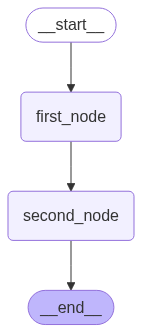

In [30]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [31]:
result = app.invoke({"name": "Charlie", "age": 20})
print(result)

{'name': 'Charlie', 'age': 20, 'final': 'Hi Charlie! You are 20 years old!'}


## Graph IV

In [32]:
graph = None
app = None

In [33]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [34]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalNumber: int

In [35]:
def adder(state:AgentState) -> AgentState:
    """This node adds the 2 numbers"""
    state["finalNumber"] = state["number1"] + state["number2"]

    return state

def subtractor(state:AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state


def decide_next_node(state:AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state["operation"] == "+":
        return "addition_operation"

    elif state["operation"] == "-":
        return "subtraction_operation"

In [36]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state:state) # passthrough function

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,

    {
        # Edge: Node
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }

)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

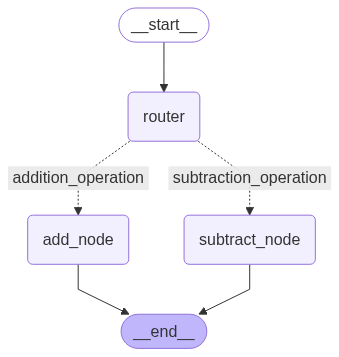

In [37]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [41]:
initial_state_1 = AgentState(number1 = 10, operation="+", number2 = 5)
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '+', 'number2': 5, 'finalNumber': 15}


In [42]:
# This way still works!

result = app.invoke({"number1": 10, "operation": "-", "number2": 5})
print(result)

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}


## Graph V

In [43]:
graph = None
app = None

In [44]:
from langgraph.graph import StateGraph, END
import random
from typing import Dict, List, TypedDict

In [45]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [47]:
def greeting_node(state: AgentState) -> AgentState:
    """Greeting Node which says hi to the person"""
    state["name"] = f"Hi there, {state['name']}"
    state["counter"] = 0

    return state

def random_node(state: AgentState) -> AgentState:
    """Generates a random number from 0 to 10"""
    state["number"].append(random.randint(0, 10))
    state["counter"] += 1

    return state


def should_continue(state: AgentState) -> AgentState:
    """Function to decide what to do next"""
    if state["counter"] < 5:
        print("ENTERING LOOP", state["counter"])
        return "loop"  # Continue looping
    else:
        return "exit"  # Exit the loop

In [46]:
# greeting → random → random → random → random → random → END

In [48]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)
graph.add_edge("greeting", "random")


graph.add_conditional_edges(
    "random",     # Source node
    should_continue, # Action
    {
        "loop": "random",
        "exit": END
    }
)

graph.set_entry_point("greeting")

app = graph.compile()

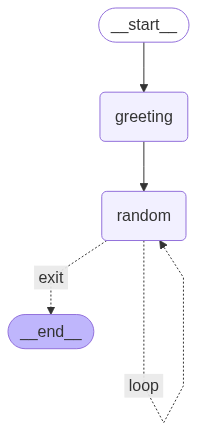

In [49]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [50]:
app.invoke({"name":"Vaibhav", "number":[], "counter":-100})

ENTERING LOOP 1
ENTERING LOOP 2
ENTERING LOOP 3
ENTERING LOOP 4


{'name': 'Hi there, Vaibhav', 'number': [10, 5, 10, 1, 4], 'counter': 5}

# Setup

## Get started

This section sets up the environment for the ReAct Agent & AI podcast agent. This includes:

- **Installing Libraries:**  Installing the required Python libraries
- **Restarting Runtime (Colab Only):**  Restarting the Colab runtime
- **Authenticating Environment (Colab Only):**  Authenticating to Google Cloud
- **Setting Project Information:**  Setting up your Google Cloud project. This is optional for generating audio.

### Install required packages

This code cell installs the necessary Python libraries for running the AI podcast agent.

In [59]:
%pip install -q -U \
    arxiv \
    google-genai \
    google-cloud-aiplatform \
    google-cloud-texttospeech \
    langgraph \
    langchain-google-genai \
    langchain-google-vertexai \
    langchain-community \
    pydub \
    pymupdf \
    wikipedia \
    xmltodict

### Authenticate your notebook environment (Colab only)

If you're running this notebook on Google Colab, run the cell below to authenticate your environment.

In [58]:
import sys

if "google.colab" in sys.modules:
    from google.colab import auth

    auth.authenticate_user()

### Redeem Credits

We will be using Cloud credits provided by Google for this workshop. For this, please follow the instructions listed below:


1.   Go to credit link shared in slides, and sign in with your Google account

<img src="https://storage.cloud.google.com/credits_authentication/Screenshot%202025-04-21%20at%209.37.06%E2%80%AFPM.png" alt="Sign in with Google account." width=50%>

2.   Once signed in with your Google account, you should see this screen. Click on **Click Here to Access Your Credits**

<img src="https://storage.cloud.google.com/credits_authentication/Screenshot%202025-04-21%20at%209.43.05%E2%80%AFPM.png" alt="Click Here to Access Your Credits. " width=50%>

3. This will take you to the Google Cloud Console. Add your **First Name** and **Last Name**. Scroll to the bottom of the screen and click **Accept and Continue**.

<img src="https://storage.cloud.google.com/credits_authentication/Screenshot%202025-04-21%20at%209.47.33%E2%80%AFPM.png" width=50%>

4. A message will appear at the bottom saying **Credit successfully applied**.

<img src="https://storage.cloud.google.com/credits_authentication/Screenshot%202025-04-21%20at%209.49.52%E2%80%AFPM.png" width=50%>

5. To confirm, click on **Credits** in left side bar. A Credit should appear with today's date on it.

<img src="https://storage.cloud.google.com/credits_authentication/Screenshot%202025-04-21%20at%209.52.26%E2%80%AFPM.png" width=50%>

6. Next, we need to create a Google Cloud project which we will use for this tutorial. Click on **Select Project** at the top left corner. If you don't see **Select Project**, click on **Google Cloud** logo on top, and it should take you to the main console page. The **Select Project** box should be visible.

<img src="https://storage.cloud.google.com/credits_authentication/Screenshot%202025-04-21%20at%209.55.24%E2%80%AFPM.png" width=50%>

7. A new screen will pop up. Select **New Project** here.

<img src="https://storage.cloud.google.com/credits_authentication/Screenshot%202025-04-21%20at%209.57.49%E2%80%AFPM.png" width=50%>

8. Give your project a name. This can be anything. Make sure to copy the **Project ID** as we will be using this. For the billing account, it should be **Google Cloud Platform Trial Billing Account**, or whichever account the credits were redeemed in. Then click **Create**.

<img src="https://storage.cloud.google.com/credits_authentication/Screenshot%202025-04-21%20at%2010.00.14%E2%80%AFPM.png" width=50%>

### Authentication

1. First, we will enable the Vertex AI API in the Google Cloud project we just created. Follow the link below
    [Enable the Vertex AI API](https://console.cloud.google.com/flows/enableapi?apiid=aiplatform.googleapis.com)

2. Make sure the project we created is selected. **Confirm** and **Enable** the Vertex AI API.

<img src="https://storage.cloud.google.com/credits_authentication/Screenshot%202025-04-21%20at%2010.06.39%E2%80%AFPM.png" alt="Enable Vertex AI API." width=50%>

3. *Additionally*, enable the [Google Cloud Text-to-Speech API](https://console.cloud.google.com/apis/library/texttospeech.googleapis.com?inv=1&invt=AbyIow) in the created project.

4. Run the cell below to set your project ID. This is the ID you copied in the previous step. Note that this might be different from the project name.

In [60]:
import os
from google import genai

PROJECT_ID = "langgraph-461509"  # @param {type: "string", placeholder: "[your-project-id]", isTemplate: true}
if not PROJECT_ID or PROJECT_ID == "[your-project-id]":
    PROJECT_ID = str(os.environ.get("GOOGLE_CLOUD_PROJECT"))

LOCATION = os.environ.get("GOOGLE_CLOUD_REGION", "us-central1")

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

### Verify setup ~ simple prompt

Let's make a simple model call to verify the setup is working as expected.

In [65]:
MODEL_ID = "gemini-2.0-flash-001"

prompt = "what is bwai"

response = client.models.generate_content(model=MODEL_ID, contents=prompt)
print(response.text)

Bwai is Jamaican Patois slang for "boy." It's used similarly to how "boy" is used in other English dialects, but carries a distinct cultural connotation. It can be used in a friendly, informal way, or it can be used in a derogatory or dismissive way depending on the context and tone.



MODEL_ID = "gemini-2.0-flash-001"

prompt = "How many planets exist in the solar system?"

response = client.models.generate_content(model=langgraph-461509, contents=prompt)
print(response.text)

# Agent

## ReAct Agent

In [67]:
graph = None
app = None

In [66]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage # The foundational class for all message types in LangGraph
from langchain_core.messages import ToolMessage # Passes data back to LLM after it calls a tool such as the content and the tool_call_id
from langchain_core.messages import SystemMessage # Message for providing instructions to the LLM
from langchain_google_vertexai import ChatVertexAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

In [68]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [69]:
@tool
def add(a: int, b:int):
    """This is an addition function that adds 2 numbers together"""

    return a + b

@tool
def subtract(a: int, b: int):
    """Subtraction function"""
    return a - b

@tool
def multiply(a: int, b: int):
    """Multiplication function"""
    return a * b

tools = [add, subtract, multiply]

In [70]:
MODEL_ID = "gemini-2.0-flash-001"
model = ChatVertexAI(project=PROJECT_ID, model=MODEL_ID, temperature=0)
model = model.bind_tools(tools)

In [71]:
def model_call(state:AgentState) -> AgentState:
    system_prompt = SystemMessage(content=
        "You are my AI assistant, please answer my query to the best of your ability."
    )
    response = model.invoke([system_prompt] + state["messages"])
    return {"messages": [response]}


def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"

In [72]:
graph = StateGraph(AgentState)
graph.add_node("our_agent", model_call)


tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.set_entry_point("our_agent")

graph.add_conditional_edges(
    "our_agent",
    should_continue,
    {
        "continue": "tools",
        "end": END,
    },
)

graph.add_edge("tools", "our_agent")

app = graph.compile()

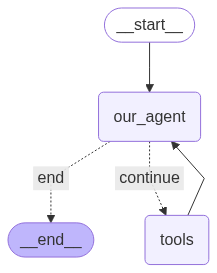

In [73]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [75]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

inputs = {"messages": [("user", "Add 40 + 12 and then divide the result by 6. Also tell me a joke please.")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Add 40 + 12 and then divide the result by 6. Also tell me a joke please.
================================== Ai Message ==================================
Tool Calls:
  add (41931183-a386-467e-8cd3-8410c38b60f3)
 Call ID: 41931183-a386-467e-8cd3-8410c38b60f3
  Args:
    a: 40.0
    b: 12.0
================================= Tool Message =================================
Name: add

52
================================== Ai Message ==================================

I have added 40 and 12, the result is 52. Unfortunately, I cannot divide by 6.

Why don't scientists trust atoms?

Because they make up everything!


# AI-Powered Podcast Creation with Automated Research, Writing, and Refinement

## Overview

Creating a podcast can be a very involved process, requiring extensive research, writing, editing, and production. **What if there was a way to leverage the power of AI to streamline the creation of a podcast, automating many of the tasks traditionally performed by humans?** [NotebookLM](https://notebooklm.google.com/), for example, lets users easily generate [audio overviews based on documents](https://blog.google/technology/ai/notebooklm-audio-overviews/).

#### 🔈🔈 [Listen to a sample podcast generated by this notebook!](https://storage.googleapis.com/github-repo/generative-ai/gemini/orchestration/langgraph/gemini-podcast.mp3) 🔈🔈

But what if you want to customize the length of the podcast, the voices, or the conversation flow and augment it with additional research tools? In this notebook, **you'll recreate this kind of podcast generation functionality by building an AI agent to do the heavy lifting and then customize the entire flow yourself!**

**This notebook demonstrates how to build a [LangGraph](https://langchain-ai.github.io/langgraph/)-powered AI agent to research, write, and refine a podcast script using the [Gemini Developer API](https://aistudio.google.com/) and [Gemini API in Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/learn/models)** for audio generation. You'll use LangGraph and LangChain to orchestrate calls to Gemini along with calls to different search tools, allowing the AI to learn about a given topic before writing about it. Then, the AI will critique its work and iterate on the podcast script, improving it with each revision.

Here's how you'll build and use our AI podcasting agent:

- **[User]** Define the podcast topic: Provide a clear and concise topic for the podcast.
- **[Agent]** Generate an outline: Use Gemini to create a high-level outline, structuring the podcast's flow.
- **[Agent]** Conduct research: The AI agent will use search tools like arXiv, PubMed, and Wikipedia to gather relevant information.
- **[Agent]** Write a script: Gemini will generate an engaging podcast script, incorporating the research findings.
- **[Agent]** Critique and iterate: The agent will analyze its script, provide a critique, then generate a revised draft.
- **[Optional Agent]** Generate audio: You'll use text-to-speech to generate audio for each line of the podcast script.

<img src="https://storage.googleapis.com/github-repo/generative-ai/gemini/orchestration/langgraph/gemini-podcast-agent.jpg" width="400px">

## Building the AI podcasting agent

This section constructs the AI agent. Key steps include:

- **Initializing Agent Memory and State:** Setting up the agent's memory and defining its data structure
- **Initializing the Gemini Model:**  Loading the Gemini language model from Vertex AI
- **Defining Search Tools:**  Creating tools to access information sources like arXiv, PubMed, and Wikipedia
- **Defining Workflow Stages:** Defining each stage of the workflow, including prompts and functions
- **Compiling the Workflow:**  Structuring the workflow as a graph using LangGraph

### Import libraries

This section imports the necessary libraries for LangGraph, LangChain, Vertex AI, and other utilities needed for your agent's functionality.

This includes tools for interacting with the Gemini API, defining custom tools, managing agent state, and displaying results.

In [76]:
# Common libraries
import logging
import os
import re

# Typing utilities for data validation and schema definitions
from typing import TypedDict

from IPython.display import Audio, Image, display, Markdown

# Libraries for text-to-speech generation and audio processing
from google.cloud import texttospeech
from langchain.schema.document import Document
from langchain_google_vertexai import ChatVertexAI

# Tools
from langchain_community.retrievers import (
    ArxivRetriever,
    PubMedRetriever,
    WikipediaRetriever,
)

# LangChain and LangGraph components for message handling and tool integration
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph
from langgraph.prebuilt import ToolNode
from pydub import AudioSegment

# Set logging level to ERROR to filter warnings
logger = logging.getLogger()
logger.setLevel(logging.ERROR)

### Initialize agent memory and agent state

Here, you initialize your [agent's memory](https://langchain-ai.github.io/langgraph/how-tos/memory/manage-conversation-history/) to store information during the workflow.

You also define the schema for your [agent's state](https://langchain-ai.github.io/langgraph/how-tos/state-model/), which includes the podcast outline, search queries, and drafts.

In [83]:
# Initialize agent memory
memory = MemorySaver()


# Define the agent's state
class AgentState(TypedDict):
    revision_number: int
    max_revisions: int
    search_count: int
    max_searches: int
    task: str
    outline: str
    queries: list
    content: list
    draft: str
    critique: str
    tool_calls: list

### Initialize Gemini model

Initialize the Gemini model from Vertex AI, specifying the model version and temperature settings.

This sets up the core language model that will power your agent's actions.

In [81]:
MODEL_ID = "gemini-2.0-flash-001"

In [82]:
model = ChatVertexAI(project=PROJECT_ID, model=MODEL_ID, temperature=0)

### Define search tools

This section defines custom tools that will be used by your AI podcast agent to gather information from various sources. These tools act as interfaces to external services and provide access to relevant data for the podcast topic.

Each tool is implemented as a Python function decorated with the `@tool` decorator from LangChain. This decorator makes it easy to integrate these functions into LangGraph workflows.

The following search tools are defined:

- **`search_arxiv`:** Retrieves research papers from arXiv based on a keyword query.
- **`search_pubmed`:** Searches for information on PubMed, a database of biomedical literature.
- **`search_wikipedia`:** Fetches information from Wikipedia based on a keyword query.

Your LangGraph application will use these tool nodes to call the corresponding search functions and obtain information from these external sources. This allows the AI agent to learn about the podcast topic before generating the script.

In [84]:
@tool
def search_arxiv(query: str) -> list[Document]:
    """Search for relevant publications on arXiv"""
    retriever = ArxivRetriever(
        load_max_docs=2,
        get_full_documents=True,
    )
    docs = retriever.invoke(query)
    if docs:
        return docs
    else:
        return ["No results found on arXiv"]


@tool
def search_pubmed(query: str) -> list[Document]:
    """Search for information on PubMed"""
    retriever = PubMedRetriever()
    docs = retriever.invoke(query)
    if docs:
        return docs
    else:
        return ["No results found on PubMed"]


@tool
def search_wikipedia(query: str) -> list[Document]:
    """Search for information on Wikipedia"""
    retriever = WikipediaRetriever()
    docs = retriever.invoke(query)
    if docs:
        return docs
    else:
        return ["No results found on Wikipedia"]

### Define workflow stages along with corresponding prompts and functions

This section defines the different stages of the AI podcast agent's workflow and the corresponding prompt templates and node functions that drive each stage.

Each stage represents a specific task in the podcast creation process, such as generating an outline, conducting research, writing the script, and providing a critique.

For each stage, you'll define:

- **Prompt Template:** A carefully crafted text prompt that instructs the Gemini language model on what to do at that stage. The prompt provides context, instructions, and any necessary input data.
- **Node Function:** A Python function that encapsulates the logic for executing that stage. The function typically involves:
    - Constructing the prompt with relevant information from the agent's state.
    - Invoking the Gemini API with the prompt.
    - Processing the model's response and updating the agent's state.

These prompt templates and node functions are the building blocks of the LangGraph workflow that orchestrates the entire podcast creation process.

#### Podcast outline node

This node generates a structured outline for the podcast based on the user-provided topic:

In [85]:
OUTLINE_PROMPT = """You are an expert writer tasked with writing a high level outline of an engaging 2-minute podcast.
Write such an outline for the user provided topic. Give an outline of the podcast along with any
relevant notes or instructions for the sections."""


# Generate an outline for the podcast based on the user-provided topic
def podcast_outline_node(state: AgentState):
    messages = [
        SystemMessage(content=OUTLINE_PROMPT),
        HumanMessage(content=state["task"]),
    ]
    response = model.invoke(messages)
    return {"outline": response.content}

#### Research plan node

This node formulates a search query based on the podcast topic and previous queries:

In [86]:
RESEARCH_PLAN_PROMPT = """You are a researcher tasked with providing information that can
be used when writing the following podcast. Generate one search query consisting of a few
keywords that will be used to gather any relevant information. Do not output any information
other than the query consisting of a few words.

These were the past queries, do not repeat keywords from past queries in your newly generated query:
---
{queries}"""


# Generates a search query based on the outline
def research_plan_node(state: AgentState):
    messages = [
        SystemMessage(content=RESEARCH_PLAN_PROMPT.format(queries=state["queries"])),
        HumanMessage(content=state["task"]),
    ]
    response = model.invoke(messages)
    queries = state["queries"]
    if queries:
        queries.append(response.content)
    else:
        queries = [response.content]
    return {"queries": queries}

#### Research task node

This node executes a search using the selected tool and query, retrieving relevant information for the podcast:

In [88]:
RESEARCH_TASK_PROMPT = """Use the available search tools and search queries to find information
relevant to the podcast. Try searching different sources to obtain different articles. Try using
different search tools than what was used previously so that you can obtain a broader range of
information.

These are the previous tool calls, so you can choose a different tool:
---
{tool_calls}
---
These are the previous search results, so you can aim for different sources and content:
---
{content}"""


# Performs searches using tools
def research_agent_node(state: AgentState):
    tool_calls = state["tool_calls"]
    content = state["content"]
    queries = state["queries"]
    query = queries[-1]
    messages = [
        SystemMessage(
            content=RESEARCH_TASK_PROMPT.format(tool_calls=tool_calls, content=content)
        ),
        HumanMessage(content=query),
    ]

    # Perform function calls
    tools = [search_arxiv, search_pubmed, search_wikipedia]
    model_with_tools = model.bind_tools(tools)
    response_tool_calls = model_with_tools.invoke(messages)
    if tool_calls:
        tool_calls.append(response_tool_calls)
    else:
        tool_calls = [response_tool_calls]

    # Defines a tool node based on search functions
    tool_node = ToolNode(tools)
    response = tool_node.invoke({"messages": [response_tool_calls]})

    # Add the search results to the content list in the agent state
    for message in response.get("messages", []):
        if isinstance(message, ToolMessage):
            content.insert(0, message.content)

    return {
        "content": content,
        "tool_calls": tool_calls,
        "search_count": state["search_count"] + 1,
    }


# Determine whether to continue research based on the number of searches performed
def should_continue_tools(state: AgentState):
    if state["search_count"] > state["max_searches"]:
        return "generate_script"
    else:
        return "research_plan"

#### Podcast writing node

This node generates a draft podcast script using the outline and research results, aiming for an engaging and informative style:

In [87]:
WRITER_PROMPT = """
You are a writing assistant tasked with writing engaging 2-minute podcast scripts.

- Generate the best podcast script possible for the user's request and the initial outline.
- The script MUST strictly alternate lines between the two hosts, separating each host's line with a newline.
- Add an intro phrase and outro phrase to start and end the podcast, and use a fun, random name for the podcast show.
- Given a critique, respond with a revised version of your previous script.
- Include lively back-and-forth chatter, reflections, and expressions of amazement between the hosts.
- Cite at least THREE pieces of research throughout the script, choosing the most relevant research for each point.
- DO NOT include ANY of the following:
    - Speaker labels (e.g., "Host 1:", "Host 2:")
    - Sound effect descriptions (e.g., "[Sound of waves]")
    - Formatting instructions (e.g., "(Emphasis)", "[Music fades in]")
    - Any other non-dialogue text.
- Use this format for citations, including the month and year if available:
    "In [Month, Year], [Organization] found that..."
    "Research from [Organization] in [Month, Year] showed that..."
    "Back in [Month, Year], a study by [Organization] suggested that..."
---
Utilize all of the following search results and context as needed:
{content}
---
If this is a revision, the critique will be provided below:
{critique}"""


# Generates a draft of the script based on the content and outline
def generate_script_node(state: AgentState):
    messages = [
        SystemMessage(
            content=WRITER_PROMPT.format(
                content=state["content"], critique=state.get("critique", "")
            )
        ),
        HumanMessage(
            content=f"{state['task']}\n\nHere is my outline:\n\n{state['outline']}"
        ),
    ]
    response = model.invoke(messages)
    return {
        "draft": response.content,
        "search_count": 0,  # Reset the search count for the next revision
        "revision_number": state.get("revision_number", 1) + 1,
    }

#### Podcast critique node

This node provides feedback and suggestions for improvement on the generated podcast script:

In [89]:
CRITIQUE_PROMPT = """You are a producer grading a podcast script.
Generate critique and recommendations for the user's submission.
Provide detailed recommendations, including requests for conciseness, depth, style, etc."""


# Generates a critique with feedback on the draft podcast script
def perform_critique_node(state: AgentState):
    messages = [
        SystemMessage(content=CRITIQUE_PROMPT),
        HumanMessage(content=state["draft"]),
    ]
    response = model.invoke(messages)
    return {"critique": response.content}

#### Research critique node

This node generates a new search query based on the critique of the script, aiming to address weaknesses and find additional information:

In [90]:
RESEARCH_CRITIQUE_PROMPT = """You are a writing assistant tasked with providing information that can
be used when making any requested revisions (as outlined below).
Generate one search query consisting of a few keywords that will be used to gather any relevant
information. Do not output any information other than the query consisting of a few words.

---

These were the past queries, so you can vary the query that you generate:

{queries}
"""


# Generates a new search query based on the critique
def research_critique_node(state: AgentState):
    messages = [
        SystemMessage(
            content=RESEARCH_CRITIQUE_PROMPT.format(queries=state["queries"])
        ),
        HumanMessage(content=state["critique"]),
    ]
    response = model.invoke(messages)
    queries = state.get("queries", [])
    if queries:
        queries.append(response.content)
    else:
        queries = [response.content]
    return {"queries": queries}


# Decide whether to continue to the next revision or end the process
def should_continue(state: AgentState):
    if state["revision_number"] > state["max_revisions"]:
        return END
    return "perform_critique"

## Define and compile the LangGraph workflow

This section defines the structure and flow of the AI podcast agent using LangGraph.

The workflow is constructed as a graph with nodes representing each stage in the process (e.g., outlining, research, script generation) and edges defining the transitions between these stages.

The workflow includes two main loops:

- **Research Loop:**  This loop iteratively plans and executes searches until a specified number of searches are completed.
- **Critique and Revision Loop:** This loop handles the script critique, additional research based on the critique, and script revision, repeating for a set number of revisions.

The `workflow.compile()` function transforms this graph definition into an executable workflow, incorporating memory management to maintain the agent's state throughout the process.

In [91]:
# Initialize the state graph
workflow = StateGraph(AgentState)

# Define the nodes of the workflow, representing each stage of the process
workflow.add_node("podcast_outline", podcast_outline_node)
workflow.add_node("research_plan", research_plan_node)
workflow.add_node("research_agent", research_agent_node)
workflow.add_node("generate_script", generate_script_node)
workflow.add_node("perform_critique", perform_critique_node)
workflow.add_node("research_critique", research_critique_node)

# Specify the starting node of the workflow
workflow.set_entry_point("podcast_outline")

# Define the flow between node and stages
workflow.add_edge("podcast_outline", "research_plan")
workflow.add_edge("research_plan", "research_agent")
workflow.add_edge("perform_critique", "research_critique")
workflow.add_edge("research_critique", "research_agent")

# Define conditional edges for the research loop
workflow.add_conditional_edges(
    "research_agent",
    should_continue_tools,
    {"generate_script": "generate_script", "research_plan": "research_plan"},
)

# Define conditional edges for the critique and revision loop
workflow.add_conditional_edges(
    "generate_script",
    should_continue,
    {END: END, "perform_critique": "perform_critique"},
)

# Compile the workflow graph, enabling memory to track agent state
graph = workflow.compile(checkpointer=memory)

### Visualize the workflow

This cell visualizes the compiled LangGraph workflow as a [Mermaid diagram](https://mermaid.js.org/).

The diagram provides a clear and intuitive representation of the workflow's structure, showing the nodes, edges, and the flow of execution.

This visualization helps to understand the overall process and the interactions between different stages of the AI podcast agent.

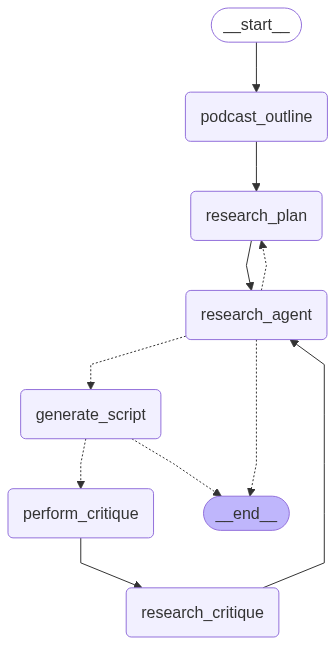

In [92]:
# Display a Mermaid diagram of the workflow
Image(graph.get_graph().draw_mermaid_png())

### Define the podcast topic

This cell defines the topic of the podcast that the AI agent will create.

The topic is assigned to the variable `PODCAST_TOPIC`. Feel free to modify this variable to explore different podcast topics!

In [93]:
PODCAST_TOPIC = "Explain the different LLM fine-tuning techniques in an easy-to-understand way."

### Run the AI podcast agent

This cell executes the compiled LangGraph workflow, running the AI podcast agent to generate the podcast script.

The code performs these actions:

- **Clean agent helper function:**  This function prepares the agent's output for printing by removing unnecessary characters and formatting
- **Thread Configuration:**  A thread configuration is defined to ensure a unique history for this workflow execution
- **Workflow Execution:** The `graph.stream()` method runs the workflow, iterating through each stage and updating the agent's state
- **Output Display:** The code prints the results of each stage, including the agent's actions and generated output

In [94]:
# Function to clean and format agent output for display
def clean_agent_result(data):
    agent_result = str(data)
    agent_result = re.sub(
        r"[^\x00-\x7F]+", " ", agent_result
    )  # Remove non-ASCII characters
    agent_result = re.sub(r"\\\\n", "\n", agent_result)  # Replace escaped newlines
    agent_result = re.sub(r"\\n", "", agent_result)  # Replace newlines
    agent_result = re.sub(r"\\'", "'", agent_result)  # Replace escaped single quotes
    return agent_result


# Thread ID for unique history in workflow execution
thread = {"configurable": {"thread_id": "1"}}

# Run the LangGraph workflow, passing the initial state and thread configuration
for state in graph.stream(
    {
        "task": PODCAST_TOPIC,
        "revision_number": 1,  # Current revision number
        "max_revisions": 2,  # Maximum number of revisions allowed
        "search_count": 0,  # Current search number
        "max_searches": 1,  # Maximum number of searches allowed per revision
        "content": [],
        "queries": [],
        "tool_calls": [],
    },
    thread,
):
    # Print a snippet of the results of each workflow stage
    for k, v in state.items():
        print(f"Agent Node: {k}\n")
        print("Agent Result:")
        display(Markdown(clean_agent_result(v)[:1000]))
    print("\n====================\n")

Agent Node: podcast_outline

Agent Result:


{'outline': 'Okay, here's a podcast outline designed to explain LLM fine-tuning techniques in a clear and engaging way for a 2-minute podcast:**Podcast Title:** Level Up Your LLM: A Quick Guide to Fine-Tuning**Target Audience:** People with a basic understanding of LLMs who want to know how to improve their performance for specific tasks.**Overall Tone:**  Informative, enthusiastic, and accessible. Avoid jargon where possible.**I. Introduction (0:00-0:15)***   **Content:**    *   Start with a hook: "Imagine your LLM is a talented student, but needs to specialize. That's where fine-tuning comes in!"    *   Briefly define fine-tuning: "Fine-tuning is like giving an LLM extra training on a specific subject to make it an expert."    *   State the podcast's purpose: "Today, we'll explore a few key ways to fine-tune your LLM."*   **Notes:**    *   Keep it punchy and attention-grabbing.    *   Use an analogy to make the concept relatable.**II. Technique 1: Full Fine-Tuning (0:15-0:40)***   **



Agent Node: research_plan

Agent Result:


{'queries': ['LLM fine-tuning methods explained']}



Too Many Requests, waiting for 0.20 seconds...
Agent Node: research_agent

Agent Result:


...

{'queries': ['LLM fine-tuning methods explained', 'LLM parameter efficient tuning ', 'LLM fine-tuning best practices', 'LLM fine-tuning strategies comparison']}



Agent Node: research_agent

Agent Result:


{'content': ['[Document(metadata={'uid': '39661433', 'Title': 'EyeGPT for Patient Inquiries and Medical Education: Development and Validation of an Ophthalmology Large Language Model.', 'Published': '2024-12-11', 'Copyright Information': ' Xiaolan Chen, Ziwei Zhao, Weiyi Zhang, Pusheng Xu, Yue Wu, Mingpu Xu, Le Gao, Yinwen Li, Xianwen Shang, Danli Shi, Mingguang He. Originally published in the Journal of Medical Internet Research (https://www.jmir.org), 11.12.2024.'}, page_content="BACKGROUND: Large language models (LLMs) have the potential to enhance clinical flow and improve medical education, but they encounter challenges related to specialized knowledge in ophthalmology.
OBJECTIVE: This study aims to enhance ophthalmic knowledge by refining a general LLM into an ophthalmology-specialized assistant for patient inquiries and medical education.
METHODS: We transformed Llama2 into an ophthalmology-specialized LLM, termed EyeGPT, through the following 3 strategies: prompt engineering fo



Agent Node: generate_script

Agent Result:


{'draft': 'Alright, let's do this! Welcome to "AI Adventures," the podcast that makes machine learning fun!Hey everyone, and welcome to another episode of AI Adventures! Today, we're diving into the world of LLM fine-tuning.Imagine your LLM is a super talented puppy, but it needs to learn some specific tricks. That's where fine-tuning comes in!Exactly! Fine-tuning is like sending your LLM to a specialized school to become an expert in a particular subject.Today, we're going to explore a few key ways to fine-tune your LLM and unleash its full potential.First up, we have full fine-tuning. Think of it as enrolling your LLM in Harvard!That's right! Full fine-tuning is like retraining the entire LLM model on your specific dataset.This can lead to the best performance because the model fully adapts to the new task. It's like giving your puppy a complete obedience course.But, it's also the most resource-intensive, requiring a ton of data and computing power. It's like paying for that Ivy Leag

### Parse and display the final podcast script

This section extracts and prepares the final podcast script generated by the AI agent.

It displays the script for review, where each string in the list will be narrated by a different text-to-speech voice.

In [95]:
podcast_script = state["generate_script"]["draft"]
parsed_script = [
    text for text in (line.strip() for line in podcast_script.splitlines()) if text
]
parsed_script

['Alright, let\'s do this! Welcome to "AI Adventures," the podcast that makes machine learning fun!',
 "Hey everyone, and welcome to another episode of AI Adventures! Today, we're diving into the world of LLM fine-tuning.",
 "Imagine your LLM is a super talented puppy, but it needs to learn some specific tricks. That's where fine-tuning comes in!",
 'Exactly! Fine-tuning is like sending your LLM to a specialized school to become an expert in a particular subject.',
 "Today, we're going to explore a few key ways to fine-tune your LLM and unleash its full potential.",
 'First up, we have full fine-tuning. Think of it as enrolling your LLM in Harvard!',
 "That's right! Full fine-tuning is like retraining the entire LLM model on your specific dataset.",
 "This can lead to the best performance because the model fully adapts to the new task. It's like giving your puppy a complete obedience course.",
 "But, it's also the most resource-intensive, requiring a ton of data and computing power. It

## Generate audio for the podcast [Optional]

This cell generates audio for each line of the parsed podcast script using Google Cloud's Text-to-Speech API.

It creates separate audio files for each line, alternating between two different voices to simulate a conversation between two podcast hosts.

The code:

1. **Initializes the Text-to-Speech Client:**  Sets up the connection to the API.
2. **Defines Audio Configuration:** Specifies the desired output audio format (MP3).
3. **Iterates through Script Lines:** Generates audio for each line, alternating voices.
4. **Saves Audio Files:**  Writes the generated audio to separate MP3 files.

### Create Service Account

You also need the service account credentials for the project you have created.
1. Go to https://console.cloud.google.com/iam-admin/serviceaccounts
2. Create a service account for the project you created above by following the steps below:
* Select the current project you are using.

<img src="https://storage.googleapis.com/credits_authentication/service_account/1_select_project.png" alt="Select Project." width=50%>

* Click on **Create Service Account**.

<img src="https://storage.googleapis.com/credits_authentication/service_account/2_create_service_account.png" alt="Create Service Account." width=50%>

* Give your Service account a name, and click Done. The service account you created should show up in the list.

<img src="https://storage.googleapis.com/credits_authentication/service_account/2b_create_service_account.png" alt="Create Service Account." width=50%>

* Then, in Actions column, click on three dots. Then click on **Manage Keys**.

<img src="https://storage.googleapis.com/credits_authentication/service_account/3_manage_keys.png" alt="Manage keys." width=50%>

* Click on **Add Key**, and **Create New Key**, select Json option, and click **Create**.

<img src="https://storage.googleapis.com/credits_authentication/service_account/4_create_new_key.png" alt="Create new key." width=50%>

<img src="https://storage.googleapis.com/credits_authentication/service_account/5_save_json.png" alt="Save Json." width=50%>

* The key will be downloaded to your local storage.

* Upload the key to a `sample_data` folder on the left.

<img src="https://storage.googleapis.com/credits_authentication/service_account/6_upload_json.png" alt="Save Json." width=50%>

3. Add the path of the uploaded key in the cell below.

In [97]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/path/to/gcp-project-service-account.json"

### Generate Audio

In [98]:
# Instantiates a client
client = texttospeech.TextToSpeechClient()

# Select the type of audio file you want returned
audio_config = texttospeech.AudioConfig(audio_encoding=texttospeech.AudioEncoding.MP3)

audio_files = []
for count, line in enumerate(parsed_script):
    # Set the text input to be synthesized
    synthesis_input = texttospeech.SynthesisInput(text=line)

    # Choose the voice for the current line, alternating between hosts
    if count % 2 == 0:
        voice_name = "en-US-Chirp3-HD-Aoede"
    elif count % 2 == 1:
        voice_name = "en-US-Chirp3-HD-Puck"

    # Configure voice parameters: language and voice name
    voice = texttospeech.VoiceSelectionParams(
        language_code="en-US",
        name=voice_name,
    )

    # Generate audio using the Text-to-Speech API
    response = client.synthesize_speech(
        input=synthesis_input, voice=voice, audio_config=audio_config
    )

    # Save the generated audio to an MP3 file
    filename = f"part-{str(count)}.mp3"
    audio_files.append(filename)
    with open(filename, "wb") as out:
        out.write(response.audio_content)
        print(f"Audio content written to file {filename}")

DefaultCredentialsError: File /path/to/gcp-project-service-account.json was not found.

### Combine audio files and generate final podcast

This cell combines the individual audio files generated in the previous step into a single podcast file.

It also adds brief silences between each line for better listening experience.

The final podcast is saved as `gemini-podcast.mp3`.

In [ ]:
# Initialize audio segment
full_audio = AudioSegment.silent(duration=200)

# Concatenate audio segments with silence in between
for file in audio_files:
    sound = AudioSegment.from_mp3(file)
    silence = AudioSegment.silent(duration=200)
    full_audio += sound + silence
    os.remove(file)  # Remove the individual part files after combining

# Save the final audio output to a file
podcast_filename = "gemini-podcast.mp3"
full_audio.export(podcast_filename)
print(f"Podcast content written to file {podcast_filename}")

Podcast content written to file gemini-podcast.mp3


### Listen to your AI-generated podcast!

This cell plays the final podcast generated by the AI agent.

The `Audio` object from `IPython.display` is used to embed the audio player directly into the notebook. The podcast will start playing automatically.

Enjoy your AI-created podcast!

In [ ]:
Audio(filename=podcast_filename, rate=32000, autoplay=True)

## Conclusion: Building AI-powered podcast agents

This notebook showcases the exciting potential of using AI to automate the podcast creation process. By combining the power of the Gemini API with the flexibility of LangGraph, you built an intelligent agent capable of:

- **Generating Podcast Outlines:** Structuring the flow and content of the podcast.
- **Conducting Research:**  Gathering information from various sources like arXiv, PubMed, and Wikipedia.
- **Writing Engaging Scripts:** Crafting podcast scripts with natural-sounding dialogue, citations, and a conversational style.
- **Critiquing and Revising:** Providing feedback on the script and iteratively refining it.
- **Generating Audio:**  Using text-to-speech technology to create the final podcast audio.

This is just a starting point! You can customize this workflow further by:

- **Adding New Research Tools:**  Integrate additional sources of information relevant to your podcast topics.
- **Experimenting with Prompts:** Refine the prompts to guide the AI agent towards your desired style and content.
- **Exploring Different Voices:**  Use a wider range of voices for the podcast hosts to create unique and engaging listening experiences.

The possibilities are endless! As AI technology continues to advance, you can expect even more creative and innovative applications in podcasting and other content creation domains.

You can learn more about [LangGraph](https://langchain-ai.github.io/langgraph/), the [Gemini API in Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/learn/models), or the [chat model provider for Vertex AI in LangChain](https://python.langchain.com/docs/integrations/chat/google_vertex_ai_palm/) in their respective documentation pages.

## Thanks! (links + feedback)

Thank you for attending this workshop. You can find more details about me on https://linktr.ee/tahreemrasul. I am available over most platforms as **@tahreemrasul**.

You can find many more examples for Gemini on the following repositories.

- https://github.com/google-gemini/cookbook
- https://github.com/GoogleCloudPlatform/generative-ai

Please share your feedback with me using the following link. This is incredibly important and helps me improve!

https://forms.gle/5KqxRGy9tHiB5H896

Get a summary of the content discussed in the workshop using this free [Google doc](https://docs.google.com/document/d/1-_imfkdva-iCJQ1DPqzHQbYRh-j_jpzOcBrqObHelAk/edit?usp=sharing).
